In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification


In [15]:

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2,
    random_state=42
)

In [16]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.coef = None
        self.intercept = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _loss(self, y, y_pred):
        n = len(y)
        eps = 1e-9                  # prevent log(0)
        return -(1/n) * np.sum(
            y * np.log(y_pred + eps) + (1-y) * np.log(1-y_pred + eps)
        )

    def train(self, X, y):
        n_samples, n_features = X.shape
        # initialize weights
        self.coef = np.zeros(n_features)
        self.intercept = 0
        for _ in range(self.epochs):
            # linear model
            z = np.dot(X, self.coef) + self.intercept

            # sigmoid prediction
            y_pred = self._sigmoid(z)

            # gradients
            error = y_pred - y
            dw = (1/n_samples) * np.dot(X.T, error)
            db = (1/n_samples) * np.sum(error)

            # update weights
            self.coef -= self.learning_rate * dw
            self.intercept -= self.learning_rate * db

    def predict_proba(self, X):
        z = np.dot(X, self.coef) + self.intercept
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)

In [17]:
model = LogisticRegression(learning_rate=0.01, epochs=1000)
model.train(X, y)

pred = model.predict(X)
accuracy = np.mean(pred == y)

print("Accuracy:", accuracy)

Accuracy: 0.975


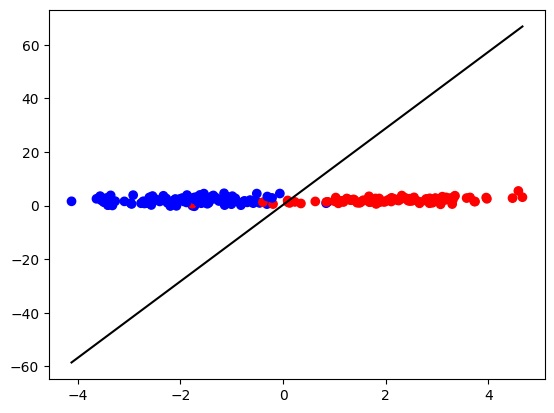

In [18]:
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr")
w1, w2 = model.coef
b = model.intercept

x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
y_vals = -(w1 * x_vals + b) / w2

plt.plot(x_vals, y_vals, color="black")
plt.show()